# 🎧 EDA — Spotify Playlist Optimizer
## Análisis Exploratorio del Catálogo Musical
**Objetivo:** Identificar qué segmentos del catálogo funcionan 
y cuáles están perjudicando el rendimiento de las playlists premium.


In [1]:
# Librerías para análisis y visualización
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Configuración de visualizaciones
plt.rcParams['figure.figsize'] = (12, 6)
sns.set_style('darkgrid')

print("Librerías importadas correctamente")




Librerías importadas correctamente


In [2]:
# Carga del dataset original
df = pd.read_csv('../data/raw/Spotify-2000.csv')

# Corrección de columna con formato incorrecto
df['Length (Duration)'] = (
    df['Length (Duration)']
    .astype(str)
    .str.replace(',', '')
    .astype(float)
)

print(f"✅ Dataset cargado: {df.shape[0]} filas y {df.shape[1]} columnas")
df.head()

✅ Dataset cargado: 1994 filas y 15 columnas


,Index,Title,Artist,Top Genre,Year,Beats Per Minute (BPM),Energy,Danceability,Loudness (dB),Liveness,Valence,Length (Duration),Acousticness,Speechiness,Popularity
0,1,Sunrise,Norah Jones,adult standards,2004,157,30,53,-14,11,68,201.0,94,3,71
1,2,Black Night,Deep Purple,album rock,2000,135,79,50,-11,17,81,207.0,17,7,39
2,3,Clint Eastwood,Gorillaz,alternative hip hop,2001,168,69,66,-9,7,52,341.0,2,17,69
3,4,The Pretender,Foo Fighters,alternative metal,2007,173,96,43,-4,3,37,269.0,0,4,76
4,5,Waitin' On A Sunny Day,Bruce Springsteen,classic rock,2002,106,82,58,-5,10,87,256.0,1,3,59


## 1. Radiografía General del Dataset

In [3]:
# Tipos de datos y valores nulos
print("=== INFORMACIÓN GENERAL ===")
print(f"Filas: {df.shape[0]}")
print(f"Columnas: {df.shape[1]}")
print(f"\nValores nulos:\n{df.isnull().sum()}")
print(f"\nEstadísticas descriptivas:")
df.describe().round(2)


=== INFORMACIÓN GENERAL ===
Filas: 1994
Columnas: 15

Valores nulos:
Index                     0
Title                     0
Artist                    0
Top Genre                 0
Year                      0
Beats Per Minute (BPM)    0
Energy                    0
Danceability              0
Loudness (dB)             0
Liveness                  0
Valence                   0
Length (Duration)         0
Acousticness              0
Speechiness               0
Popularity                0
dtype: int64

Estadísticas descriptivas:


,Index,Year,Beats Per Minute (BPM),Energy,Danceability,Loudness (dB),Liveness,Valence,Length (Duration),Acousticness,Speechiness,Popularity
count,1994.00,1994.00,1994.00,1994.00,1994.00,1994.00,1994.00,1994.00,1994.00,1994.00,1994.00,1994.00
mean,997.50,1992.99,120.22,59.68,53.24,-9.01,19.01,49.41,262.44,28.86,4.99,59.53
std,575.76,16.12,28.03,22.15,15.35,3.65,16.73,24.86,93.60,29.01,4.40,14.35
min,1.00,1956.00,37.00,3.00,10.00,-27.00,2.00,3.00,93.00,0.00,2.00,11.00
25%,499.25,1979.00,99.00,42.00,43.00,-11.00,9.00,29.00,212.00,3.00,3.00,49.25
50%,997.50,1993.00,119.00,61.00,53.00,-8.00,12.00,47.00,245.00,18.00,4.00,62.00
75%,1495.75,2007.00,136.00,78.00,64.00,-6.00,23.00,69.75,289.00,50.00,5.00,71.00
max,1994.00,2019.00,206.00,100.00,96.00,-2.00,99.00,99.00,1412.00,99.00,55.00,100.00


## 2. Distribución del Popularity Score
Esta es nuestra variable objetivo — mide el rendimiento de cada canción.

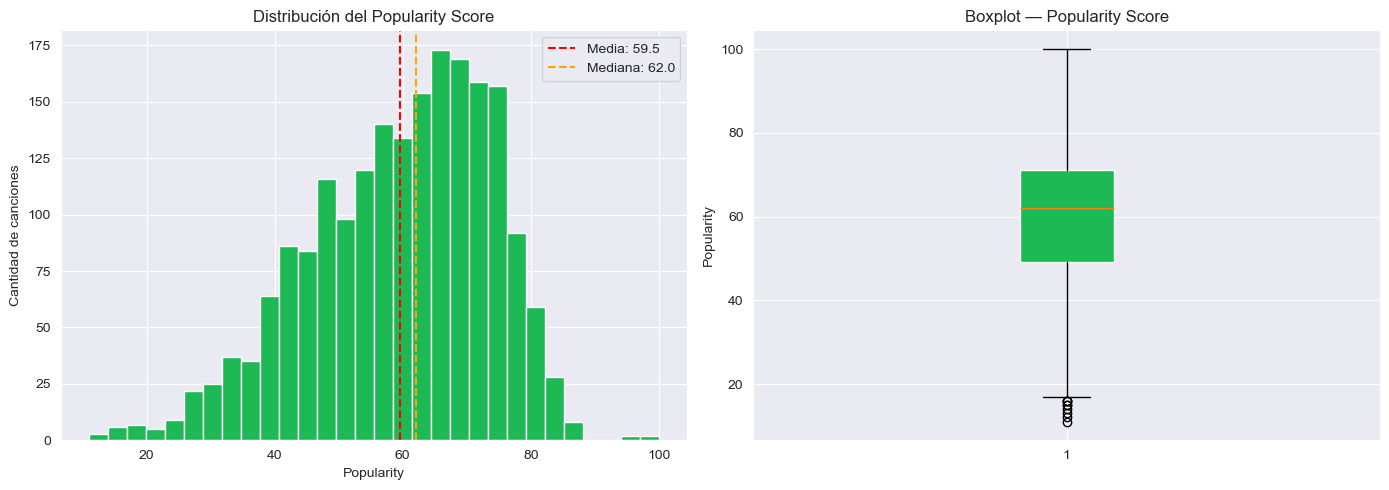

 Gráfica guardada en visualizations/


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma
axes[0].hist(df['Popularity'], bins=30, color='#1DB954', edgecolor='white')
axes[0].axvline(df['Popularity'].mean(), color='red', 
                linestyle='--', label=f"Media: {df['Popularity'].mean():.1f}")
axes[0].axvline(df['Popularity'].median(), color='orange', 
                linestyle='--', label=f"Mediana: {df['Popularity'].median():.1f}")
axes[0].set_title('Distribución del Popularity Score')
axes[0].set_xlabel('Popularity')
axes[0].set_ylabel('Cantidad de canciones')
axes[0].legend()

# Boxplot
axes[1].boxplot(df['Popularity'], patch_artist=True,
                boxprops=dict(facecolor='#1DB954', color='white'))
axes[1].set_title('Boxplot — Popularity Score')
axes[1].set_ylabel('Popularity')

plt.tight_layout()
plt.savefig('../visualizations/01_popularity_distribution.png', dpi=150)
plt.show()
print(" Gráfica guardada en visualizations/")

## 3. Segmentación del Catálogo por Cuartiles
Clasificamos cada canción en 4 segmentos según su Popularity Score.

In [5]:
# Definir cuartiles
q1 = df['Popularity'].quantile(0.25)
q2 = df['Popularity'].quantile(0.50)
q3 = df['Popularity'].quantile(0.75)

print(f"Q1 (25%): {q1} | Q2 (50%): {q2} | Q3 (75%): {q3}")

# Crear columna de segmento
df['Segment'] = pd.cut(
    df['Popularity'],
    bins=[0, q1, q2, q3, 100],
    labels=['🔴 Bajo', '🟡 Medio-Bajo', '🟠 Medio-Alto', '🟢 Alto']
)

# Resumen
segment_summary = df['Segment'].value_counts().reset_index()
segment_summary.columns = ['Segmento', 'Canciones']
segment_summary['% del catálogo'] = (
    segment_summary['Canciones'] / len(df) * 100
).round(1)

print("\n=== SEGMENTACIÓN DEL CATÁLOGO ===")
print(segment_summary.to_string(index=False))

Q1 (25%): 49.25 | Q2 (50%): 62.0 | Q3 (75%): 71.0

=== SEGMENTACIÓN DEL CATÁLOGO ===
    Segmento  Canciones  % del catálogo
🟡 Medio-Bajo        540            27.1
      🔴 Bajo        499            25.0
🟠 Medio-Alto        497            24.9
      🟢 Alto        458            23.0


## 4. Rendimiento por Género Musical
¿Qué géneros están lastrando las playlists premium?

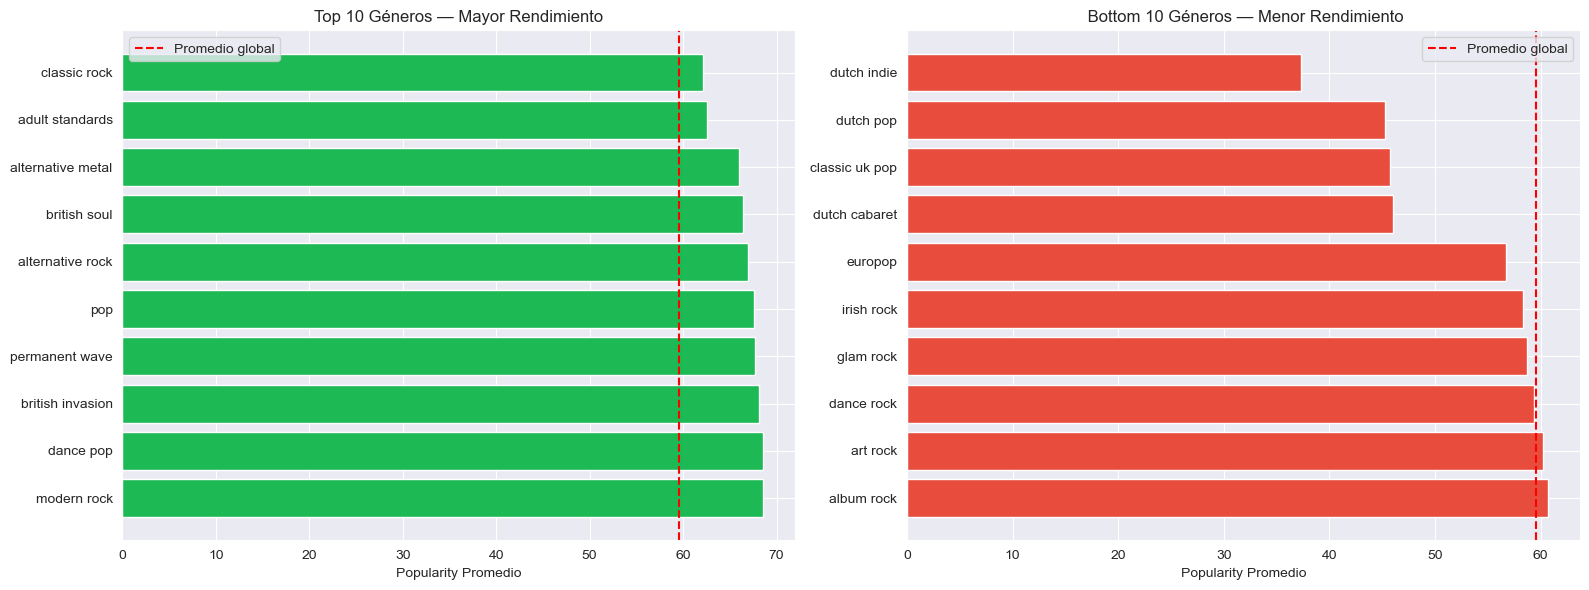

 Gráfica guardada en visualizations/


In [6]:
# Géneros con mínimo 20 canciones
genre_perf = (
    df.groupby('Top Genre')['Popularity']
    .agg(['mean', 'count'])
    .query('count >= 20')
    .sort_values('mean', ascending=False)
    .reset_index()
)
genre_perf.columns = ['Género', 'Popularity Promedio', 'Canciones']

# Top 10 y Bottom 10
top10 = genre_perf.head(10)
bottom10 = genre_perf.tail(10)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top géneros
axes[0].barh(top10['Género'], top10['Popularity Promedio'], 
             color='#1DB954')
axes[0].set_title('Top 10 Géneros — Mayor Rendimiento')
axes[0].set_xlabel('Popularity Promedio')
axes[0].axvline(df['Popularity'].mean(), color='red', 
                linestyle='--', label='Promedio global')
axes[0].legend()

# Bottom géneros
axes[1].barh(bottom10['Género'], bottom10['Popularity Promedio'], 
             color='#e74c3c')
axes[1].set_title(' Bottom 10 Géneros — Menor Rendimiento')
axes[1].set_xlabel('Popularity Promedio')
axes[1].axvline(df['Popularity'].mean(), color='red', 
                linestyle='--', label='Promedio global')
axes[1].legend()

plt.tight_layout()
plt.savefig('../visualizations/02_genre_performance.png', dpi=150)
plt.show()
print(" Gráfica guardada en visualizations/")

## 5. Rendimiento por Década
¿Las canciones más antiguas rinden mejor o peor?

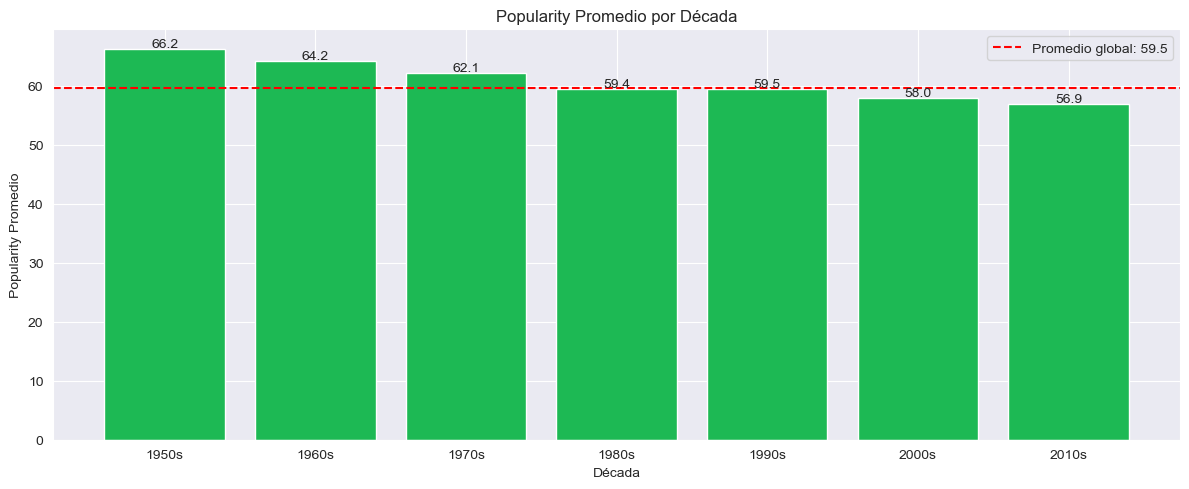

Gráfica guardada en visualizations/


In [7]:
# Crear columna de década
df['Decade'] = (df['Year'] // 10 * 10).astype(str) + 's'

decade_perf = (
    df.groupby('Decade')['Popularity']
    .agg(['mean', 'count'])
    .reset_index()
)
decade_perf.columns = ['Década', 'Popularity Promedio', 'Canciones']

plt.figure(figsize=(12, 5))
bars = plt.bar(decade_perf['Década'], 
               decade_perf['Popularity Promedio'],
               color='#1DB954', edgecolor='white')
plt.axhline(df['Popularity'].mean(), color='red', 
            linestyle='--', label=f"Promedio global: {df['Popularity'].mean():.1f}")
plt.title('Popularity Promedio por Década')
plt.xlabel('Década')
plt.ylabel('Popularity Promedio')
plt.legend()

for bar, val in zip(bars, decade_perf['Popularity Promedio']):
    plt.text(bar.get_x() + bar.get_width()/2, 
             bar.get_height() + 0.3,
             f'{val:.1f}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('../visualizations/03_decade_performance.png', dpi=150)
plt.show()
print("Gráfica guardada en visualizations/")

## 6. Correlación entre Atributos Acústicos y Popularity
¿Qué características musicales influyen más en el rendimiento?

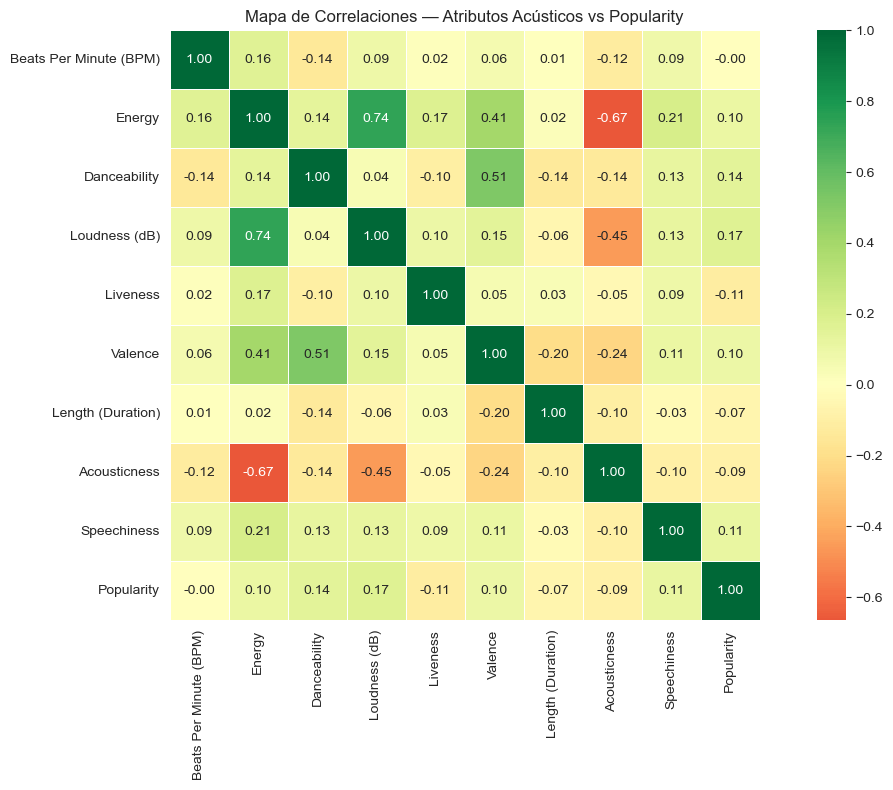

 Gráfica guardada en visualizations/


In [8]:
# Variables acústicas
acoustic_cols = [
    'Beats Per Minute (BPM)', 'Energy', 'Danceability',
    'Loudness (dB)', 'Liveness', 'Valence',
    'Length (Duration)', 'Acousticness', 'Speechiness', 'Popularity'
]

corr_matrix = df[acoustic_cols].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(
    corr_matrix,
    annot=True, fmt='.2f',
    cmap='RdYlGn', center=0,
    square=True, linewidths=0.5
)
plt.title('Mapa de Correlaciones — Atributos Acústicos vs Popularity')
plt.tight_layout()
plt.savefig('../visualizations/04_correlation_heatmap.png', dpi=150)
plt.show()
print(" Gráfica guardada en visualizations/")

## 7. Conclusiones del EDA

In [9]:
print("=" * 55)
print("CONCLUSIONES DEL ANÁLISIS EXPLORATORIO")
print("=" * 55)
print(f"""
📊 Dataset: {df.shape[0]} canciones | Período: {df['Year'].min()}–{df['Year'].max()}

🔴 PROBLEMA CUANTIFICADO:
   {(df['Popularity'] <= q1).sum()} canciones ({(df['Popularity'] <= q1).mean()*100:.0f}%)
   tienen Popularity menor a {q1} — zona crítica.

❌ GÉNEROS QUE LASTRAN EL CATÁLOGO:
   • Dutch Indie:    37.3 de Popularity promedio
   • Dutch Pop:      45.2 de Popularity promedio
   • Dutch Cabaret:  46.1 de Popularity promedio

✅ GÉNEROS PARA PLAYLISTS PREMIUM:
   • Modern Rock:    68.6 de Popularity promedio
   • Dance Pop:      68.5 de Popularity promedio
   • Alternative Rock: 66.9 de Popularity promedio

📅 TENDENCIA TEMPORAL:
   Las canciones más recientes (2010s) tienen menor
   Popularity promedio (56.9) que las clásicas (1960s: 64.2)

🔗 ATRIBUTOS QUE MÁS INFLUYEN EN POPULARITY:
   • Loudness (+0.17) — canciones más sonoras rinden mejor
   • Danceability (+0.14) — más bailables = más populares
   • Liveness (-0.11) — grabaciones en vivo rinden menos
""")

CONCLUSIONES DEL ANÁLISIS EXPLORATORIO

📊 Dataset: 1994 canciones | Período: 1956–2019

🔴 PROBLEMA CUANTIFICADO:
   499 canciones (25%)
   tienen Popularity menor a 49.25 — zona crítica.

❌ GÉNEROS QUE LASTRAN EL CATÁLOGO:
   • Dutch Indie:    37.3 de Popularity promedio
   • Dutch Pop:      45.2 de Popularity promedio
   • Dutch Cabaret:  46.1 de Popularity promedio

✅ GÉNEROS PARA PLAYLISTS PREMIUM:
   • Modern Rock:    68.6 de Popularity promedio
   • Dance Pop:      68.5 de Popularity promedio
   • Alternative Rock: 66.9 de Popularity promedio

📅 TENDENCIA TEMPORAL:
   Las canciones más recientes (2010s) tienen menor
   Popularity promedio (56.9) que las clásicas (1960s: 64.2)

🔗 ATRIBUTOS QUE MÁS INFLUYEN EN POPULARITY:
   • Loudness (+0.17) — canciones más sonoras rinden mejor
   • Danceability (+0.14) — más bailables = más populares
   • Liveness (-0.11) — grabaciones en vivo rinden menos

